# =============================================
# Phase 3: Clustering - Customer Segmentation
# Customer Intelligence System
# =============================================

In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib

import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('../data/Country-data.csv')

In [3]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
# Features for clustering 
features = ['child_mort', 'exports', 'health', 'imports', 
            'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

X = df[features].copy()

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled successfully!")
print("Shape of scaled data:", X_scaled.shape)

# Save scaler for later use in Streamlit
joblib.dump(scaler, '../models/scaler.pkl')
print("Scaler saved in models folder!")

Data scaled successfully!
Shape of scaled data: (167, 9)
Scaler saved in models folder!


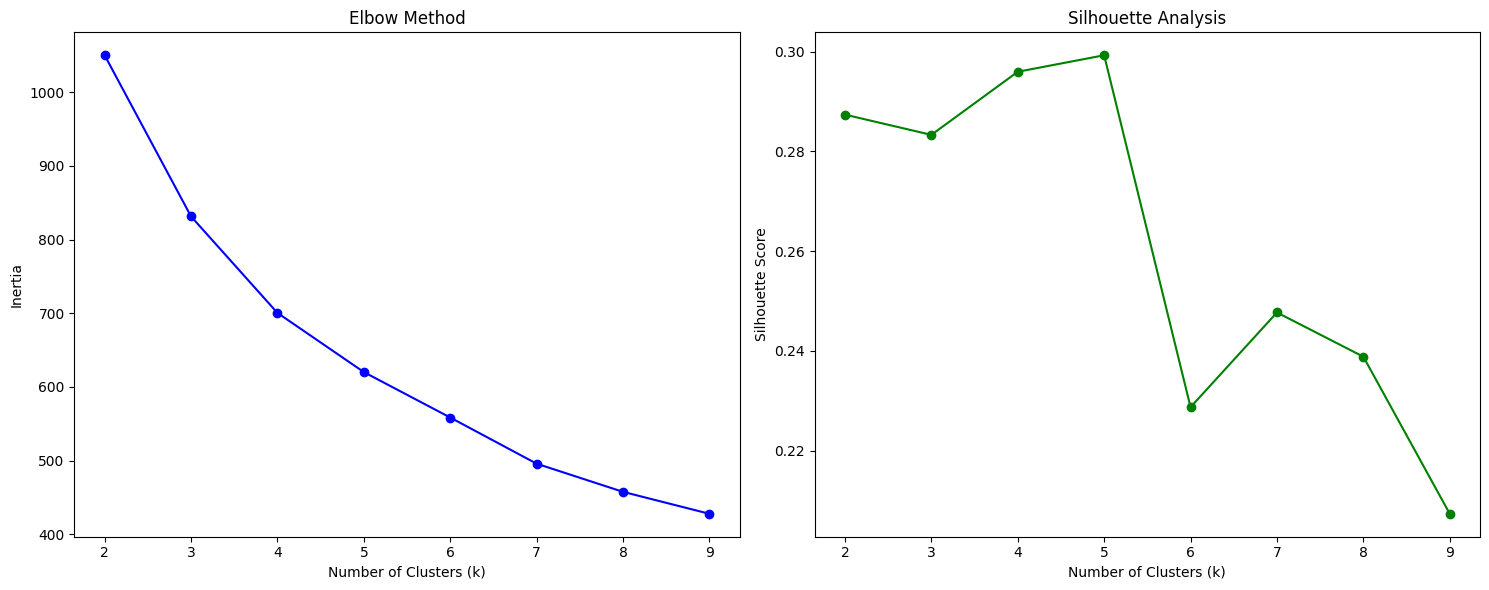

In [6]:
# Elbow Method
inertia = []
silhouette_scores = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow and Silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(K, inertia, 'bo-', marker='o')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(K, silhouette_scores, 'go-', marker='o')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')

plt.tight_layout()
plt.show()

In [7]:
# Final K-Means Model
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Save the model
joblib.dump(kmeans, '../models/kmeans_model.pkl')
print("K-Means model saved successfully!")

K-Means model saved successfully!


In [9]:
# Analyze each cluster
cluster_profile = df.groupby('Cluster')[features].mean().round(2)
cluster_profile['No_of_Countries'] = df['Cluster'].value_counts().sort_index()

print("=== Cluster Profile ===")
display(cluster_profile)

# Map cluster numbers to meaningful business names
cluster_names = {
    0: "Developed Economies",
    1: "Developing Economies", 
    2: "Underdeveloped Economies"
}

df['Cluster_Name'] = df['Cluster'].map(cluster_names)

# Show sample countries from each cluster
print("\nSample Countries from Each Cluster:")
for cluster in range(3):
    print(f"\n{cluster_names[cluster]}:")
    sample = df[df['Cluster'] == cluster][['country', 'gdpp', 'income', 'child_mort', 'life_expec']].head(5)
    display(sample)

=== Cluster Profile ===


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,No_of_Countries
Cluster,,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44,36
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38,47
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45,84



Sample Countries from Each Cluster:

Developed Economies:


,country,gdpp,income,child_mort,life_expec
7,Australia,51900,41400,4.8,82.0
8,Austria,46900,43200,4.3,80.5
11,Bahrain,20700,41100,8.6,76.0
15,Belgium,44400,41100,4.5,80.0
23,Brunei,35300,80600,10.5,77.1



Developing Economies:


,country,gdpp,income,child_mort,life_expec
0,Afghanistan,553,1610,90.2,56.2
3,Angola,3530,5900,119.0,60.1
17,Benin,758,1820,111.0,61.8
21,Botswana,6350,13300,52.5,57.1
25,Burkina Faso,575,1430,116.0,57.9



Underdeveloped Economies:


,country,gdpp,income,child_mort,life_expec
1,Albania,4090,9930,16.6,76.3
2,Algeria,4460,12900,27.3,76.5
4,Antigua and Barbuda,12200,19100,10.3,76.8
5,Argentina,10300,18700,14.5,75.8
6,Armenia,3220,6700,18.1,73.3


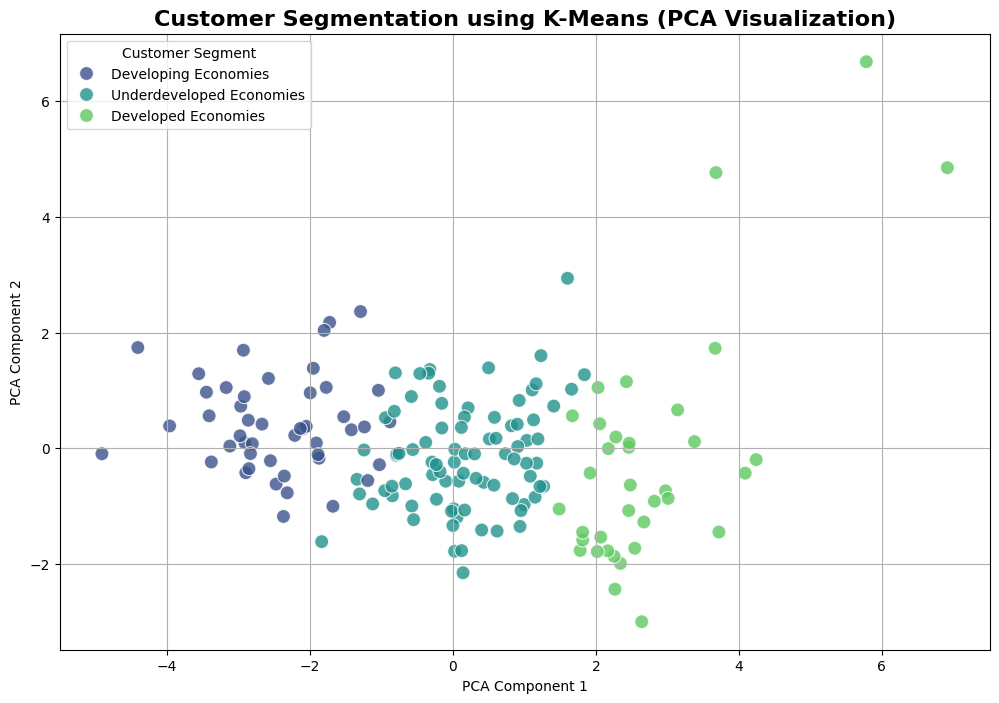

In [10]:
# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)

df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_Name', data=df, palette='viridis', s=100, alpha=0.8)
plt.title('Customer Segmentation using K-Means (PCA Visualization)', fontsize=16, fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Customer Segment')
plt.grid(True)
plt.show()

In [11]:
best_k = 3  # change after checking the elbow plot
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print('Silhouette Score:', silhouette_score(X_scaled, df['kmeans_cluster']))
df[['country', 'kmeans_cluster']].head() if 'country' in df.columns else df[['kmeans_cluster']].head()

Silhouette Score: 0.28329575683463126


,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


In [12]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(df['dbscan_cluster'].value_counts().sort_index())

dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64
